3.Climate change

1.Libraries & Tools

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import shap



2.Data Loading and Preview

In [2]:
# Load dataset
data = pd.read_csv('/content/climate_nasa.csv')



In [3]:
# Quick preview
print(data.head())
print(data.info())
print(data.describe())

                       date  likesCount  \
0  2022-09-07T17:12:32.000Z           2   
1  2022-09-08T14:51:13.000Z           0   
2  2022-09-07T17:19:41.000Z           1   
3  2022-09-08T00:51:30.000Z           4   
4  2022-09-07T19:06:20.000Z          16   

                                         profileName  commentsCount  \
0  4dca617d86b3fdce80ba7e81fb16e048c9cd9798cdfd6d...            NaN   
1  518ab97f2d115ba5b6f03b2fba2ef2b120540c9681288b...            NaN   
2  d82e8e24eb633fd625b0aef9b3cb625cfb044ceb8483e1...            3.0   
3  37a509fa0b5177a2233c7e2d0e2b2d6916695fa9fba3f2...            NaN   
4  e54fbbd42a729af9d04d9a5cc1f9bbfe8081a31c219ecb...           26.0   

                                                text  
0  Neat comparison I have not heard it before.\n ...  
1  An excellent way to visualise the invisible! T...  
2  Does the CO2/ghg in the troposphere affect the...  
3  excellent post! I defo feel the difference - o...  
4  Yes, and carbon dioxide does not har

3.Handling Missing Values & Formatting

In [4]:
# Handle missing values
data['commentsCount'] = data['commentsCount'].fillna(0)

# Convert date column to datetime
data['date'] = pd.to_datetime(data['date'], errors='coerce')

# Drop rows with missing text (optional, depending on analysis)
data = data.dropna(subset=['text'])

print(data.info())
print(data.head())


<class 'pandas.core.frame.DataFrame'>
Index: 504 entries, 0 to 521
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   date           504 non-null    datetime64[ns, UTC]
 1   likesCount     504 non-null    int64              
 2   profileName    504 non-null    object             
 3   commentsCount  504 non-null    float64            
 4   text           504 non-null    object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(1), object(2)
memory usage: 23.6+ KB
None
                       date  likesCount  \
0 2022-09-07 17:12:32+00:00           2   
1 2022-09-08 14:51:13+00:00           0   
2 2022-09-07 17:19:41+00:00           1   
3 2022-09-08 00:51:30+00:00           4   
4 2022-09-07 19:06:20+00:00          16   

                                         profileName  commentsCount  \
0  4dca617d86b3fdce80ba7e81fb16e048c9cd9798cdfd6d...            0.0   
1  518ab97f2d115

4.Feature Engineering: Text & Sentiment Variables

In [5]:
# Feature Engineering

# Text length (number of characters)
data['text_length'] = data['text'].apply(len)

# Word count
data['word_count'] = data['text'].apply(lambda x: len(x.split()))

# Sentiment score (using TextBlob for simplicity)
from textblob import TextBlob
data['sentiment'] = data['text'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Extract year and month from date
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month

print(data[['likesCount','commentsCount','text_length','word_count','sentiment','year','month']].head())


   likesCount  commentsCount  text_length  word_count  sentiment  year  month
0           2            0.0          173          32   0.000000  2022      9
1           0            0.0           51           8   0.600000  2022      9
2           1            3.0          108          16   0.000000  2022      9
3           4            0.0           94          19   0.053571  2022      9
4          16           26.0          128          24  -0.375000  2022      9


In [6]:
# Define features and target
X = data[['commentsCount', 'text_length', 'word_count', 'sentiment', 'year', 'month']]
y = data['likesCount']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (403, 6)
Test set size: (101, 6)


In [7]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train XGBoost model
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


MAE: 6.013524055480957
MSE: 179.9161834716797
R²: 0.2509390711784363


## 5.Model Evaluation: Actual vs Predicted Likes (XGBoost)


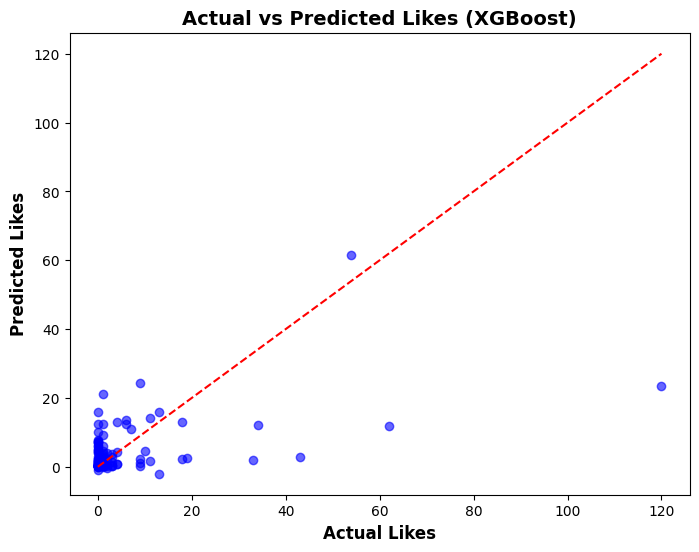

In [8]:
# Predicted vs Actual plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel("Actual Likes", fontsize=12, fontweight='bold', color='black')
plt.ylabel("Predicted Likes", fontsize=12, fontweight='bold', color='black')
plt.title("Actual vs Predicted Likes (XGBoost)", fontsize=14, fontweight='bold', color='black')

plt.show()


## 6 .SHAP Analysis: Feature Importance in Engagement Prediction


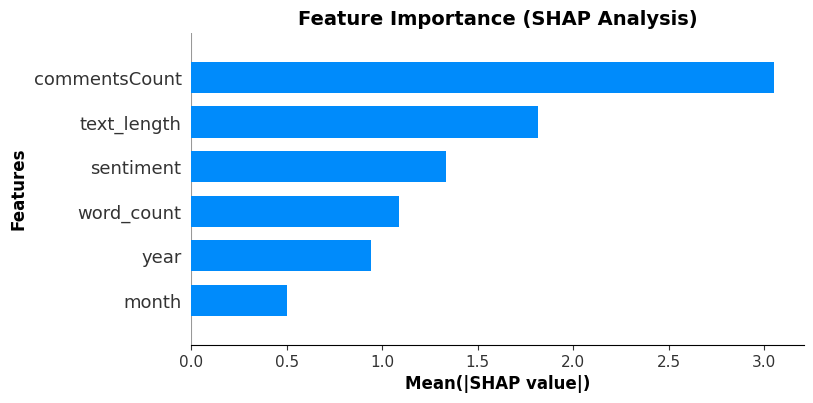

In [9]:
# SHAP analysis
explainer = shap.Explainer(model, X_train_scaled)
shap_values = explainer(X_test_scaled)

# Summary plot (feature importance) with black bold text
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.xlabel("Mean(|SHAP value|)", fontsize=12, fontweight='bold', color='black')
plt.ylabel("Features", fontsize=12, fontweight='bold', color='black')
plt.title("Feature Importance (SHAP Analysis)", fontsize=14, fontweight='bold', color='black')
plt.show()


## 7 SHAP Analysis: Distribution of Feature Impact


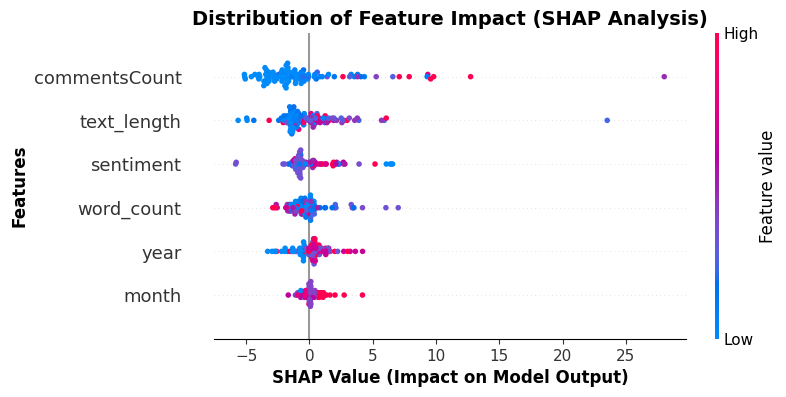

In [10]:
# Detailed plot (distribution of impact per feature)
shap.summary_plot(shap_values, X_test, show=False)

plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=12, fontweight='bold', color='black')
plt.ylabel("Features", fontsize=12, fontweight='bold', color='black')
plt.title("Distribution of Feature Impact (SHAP Analysis)", fontsize=14, fontweight='bold', color='black')

plt.show()


## 8  .SHAP Force Plot: Individual Prediction Explanation


In [11]:
# Pick one test sample (e.g., the first one)
index = 0
sample = X_test_scaled[index].reshape(1, -1)

# Explain this prediction
explainer = shap.Explainer(model, X_train_scaled)
shap_values_single = explainer(sample)

# Force plot for individual prediction
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values_single.values,
    X_test.iloc[index]
)


 9 .Sentiment Analysis: Distribution and Engagement Impact


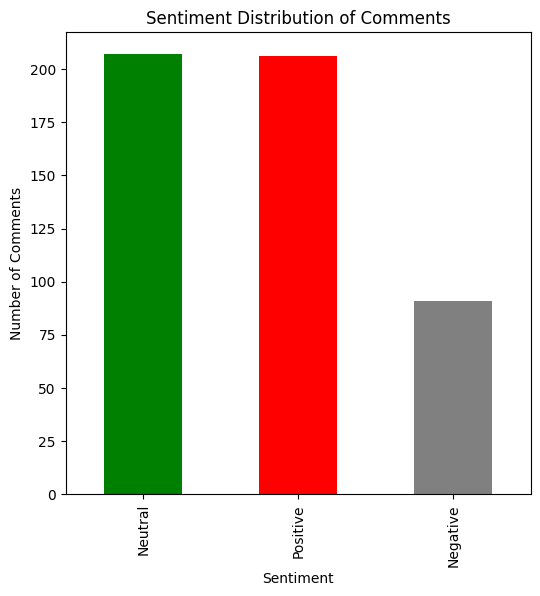

                 likesCount  commentsCount
sentiment_label                           
Negative           5.582418       5.626374
Neutral            2.439614       2.777778
Positive           6.995146       4.975728


In [12]:
# Sentiment distribution
data['sentiment_label'] = data['sentiment'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral'))

# Count distribution
sentiment_counts = data['sentiment_label'].value_counts()

# Plot sentiment distribution
plt.figure(figsize=(6,6))
sentiment_counts.plot(kind='bar', color=['green','red','gray'])
plt.title("Sentiment Distribution of Comments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()

# Compare average likes & comments by sentiment
sentiment_group = data.groupby('sentiment_label')[['likesCount','commentsCount']].mean()
print(sentiment_group)


## 10 .Sentiment-Based Engagement: Average Likes & Comments


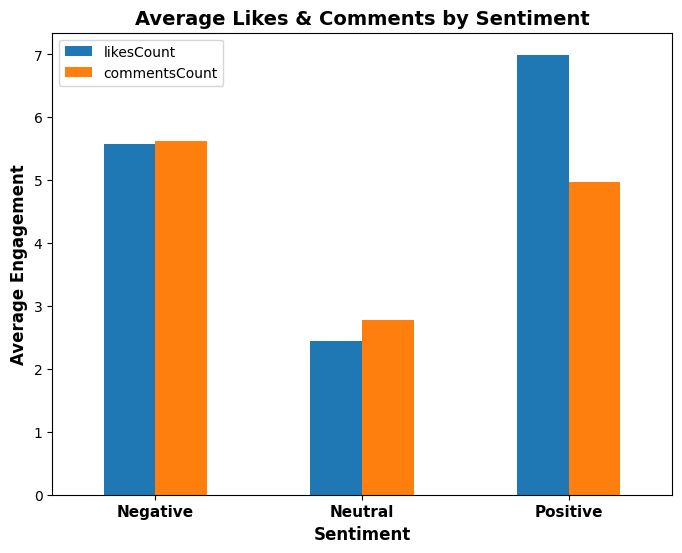

In [13]:
# Plot comparison
sentiment_group.plot(kind='bar', figsize=(8,6))

plt.title("Average Likes & Comments by Sentiment", fontsize=14, fontweight='bold', color='black')
plt.ylabel("Average Engagement", fontsize=12, fontweight='bold', color='black')
plt.xlabel("Sentiment", fontsize=12, fontweight='bold', color='black')
plt.xticks(rotation=0, fontsize=11, fontweight='bold', color='black')

plt.show()


## Saving Cleaned Dataset for Reuse


In [14]:
# Save cleaned dataset to CSV
data.to_csv("clean_climate_nasa.csv", index=False)
from google.colab import files
files.download("clean_climate_nasa.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Insights

Feature Importance (SHAP Analysis)

commentsCount is the strongest driver of likes — engagement attracts engagement.

text_length and word_count show that longer, more detailed comments tend to receive more likes, though extremes can reduce impact.

sentiment plays a measurable role: positive comments generally boost likes, while negative ones reduce them.

year and month have weaker influence, suggesting engagement is more content-driven than seasonal.

Individual Prediction Explanations (Force Plots)

SHAP force plots revealed how specific features push predictions up or down.

Example: A long comment with many replies was predicted to get more likes, while being from 2020 or having fewer words reduced the prediction.

This transparency makes the model interpretable at the single-comment level.

Trend Analysis

Engagement (likes) fluctuated significantly over time, with spikes around October 2021 and drops in early 2023.

Sentiment remained relatively stable across years, showing that public tone did not shift much even when engagement did.

Sentiment Distribution & Engagement

Neutral and positive comments dominate the dataset, while negative comments are fewer.

Positive comments attract the most likes, negative comments trigger replies, and neutral comments receive the least interaction.

This highlights the role of emotional tone in shaping engagement